# 07c — Explainable ML for Bag‑of‑Features → Property

Author: Aditya Raghavan

Idea: Sergei Kalinin and Utkarsh Pratiush


This notebook trains an explainable regressor on **tabular / bag‑of‑features** data (e.g., composition descriptors, hand‑crafted image features, peak features, metadata) and visualizes **feature importance via learnable attention weights**.

## What this notebook does

Given a dataset of the form:

- **X**: a table of shape `(N_samples, N_features)`  
- **y**: a target property of shape `(N_samples,)`

it will:

1. Load a CSV (or assemble arrays you already have).
2. Split into train/val/test (with reproducible seeds).
3. Train:
   - **Baseline MLP regressor**
   - **Attention Pooling regressor** (learns per‑feature attention weights)
4. Evaluate performance (RMSE/MAE/R², parity plots).
5. Explain predictions:
   - **Per‑sample attention** over features
   - **Global mean attention** across the dataset
   - Optional **masking sanity check**

In [1]:
# ============================
# 0) Setup
# ============================
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE: cpu


## 1) Load your Bag‑of‑Features dataset

### Recommended CSV format

A single CSV where:
- each row = one sample
- columns include feature columns + one target column

Example:

| sample_id | f1 | f2 | f3 | ... | target |
|---|---:|---:|---:|---|---:|
| s0001 | 0.12 | 4.6 | -1.2 | ... | 0.83 |

### Minimal requirements
- All feature columns must be **numeric** (float/int).
- Missing values should be handled (drop or impute).
- Target column should be numeric.

### If you also have coordinates (x,y)
You can keep `x` and `y` columns in the CSV; we’ll exclude them from features by name.

In [2]:
# ============================
# 1A) Configure your dataset
# ============================

CSV_PATH = "/mnt/data/your_features.csv"   # <-- change this
TARGET_COL = "target"                     # <-- change this

# Optional columns to exclude from features if present
NON_FEATURE_COLS = ["sample_id", "id", "x", "y", "row", "col"]

# Quick demo without any files:
MAKE_SYNTHETIC = True

In [3]:
# ============================
# 1B) Load data
# ============================

if MAKE_SYNTHETIC:
    # Synthetic dataset: target depends on a few features + noise
    N, D = 1200, 64
    rng = np.random.default_rng(0)
    X = rng.normal(size=(N, D)).astype(np.float32)

    # ground-truth sparse weights
    true_idx = np.array([3, 11, 25, 40])
    w = np.zeros(D, dtype=np.float32)
    w[true_idx] = np.array([2.0, -1.5, 1.0, 0.8], dtype=np.float32)

    y = (X @ w + 0.2 * rng.normal(size=N)).astype(np.float32)

    feature_names = [f"f{i}" for i in range(D)]
    df = pd.DataFrame(X, columns=feature_names)
    df[TARGET_COL] = y

    print("Synthetic df:", df.shape)
else:
    df = pd.read_csv(CSV_PATH)
    print("Loaded df:", df.shape)

    assert TARGET_COL in df.columns, f"TARGET_COL='{TARGET_COL}' not found. Columns: {list(df.columns)[:20]}..."

    # Drop rows with missing target
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    # Choose feature columns
    feature_cols = [c for c in df.columns if c != TARGET_COL and c not in NON_FEATURE_COLS]
    # Keep only numeric feature columns
    num_feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    dropped = sorted(set(feature_cols) - set(num_feature_cols))
    if dropped:
        print("Dropping non-numeric feature columns:", dropped)

    feature_names = num_feature_cols

    # Simple missing handling: drop rows with any NaNs in features
    df = df.dropna(subset=feature_names).reset_index(drop=True)

print("N samples:", len(df), "N features:", len(feature_names))

Synthetic df: (1200, 65)
N samples: 1200 N features: 64


In [4]:
# ============================
# 1C) Build arrays + scaling + split
# ============================

X = df[feature_names].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)

# Standardize features (recommended for mixed-scale descriptors)
scaler = StandardScaler()
Xz = scaler.fit_transform(X).astype(np.float32)

# Train/val/test split
X_train, X_tmp, y_train, y_tmp = train_test_split(Xz, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

print("Split:", X_train.shape, X_val.shape, X_test.shape)

# Torch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train).unsqueeze(1)
X_val_t   = torch.from_numpy(X_val)
y_val_t   = torch.from_numpy(y_val).unsqueeze(1)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test).unsqueeze(1)

BATCH = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH, shuffle=False)

Split: (840, 64) (180, 64) (180, 64)


## 2) Models

### Baseline: MLP
A standard fully‑connected regressor.

### Explainable: Feature‑Attention Pooling (bag‑of‑features)
We represent each feature as a token embedding and learn attention weights over features:

- learns **per‑feature importance** (instance‑specific)
- includes **temperature / tau** controlling attention concentration

> Because a bag of features has **no natural ordering**, “smoothness along an axis” is not meaningful by default.
> If you later group features (e.g., composition vs process vs microstructure), you can add group‑wise regularizers.

In [5]:
# ============================
# 2A) Baseline MLP
# ============================
class MLPRegressor(nn.Module):
    def __init__(self, d_in, d_hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

# ============================
# 2B) Feature-Attention Pooling regressor
# ============================
class FeatureAttentionRegressor(nn.Module):
    """
    Unordered feature tokens:
      - Each scalar feature x_j becomes a token embedding via a small linear proj.
      - Add a learnable feature-ID embedding so tokens are distinguishable.
      - A learnable query attends to tokens to produce a pooled representation.
      - A small head predicts y.

    Returns:
      y_hat, attn (B, D)
    """
    def __init__(self, d_features, d_model=64, d_head=128, dropout=0.1, learn_tau=True, init_tau=1.0):
        super().__init__()
        self.d_features = d_features
        self.d_model = d_model

        # scalar -> d_model
        self.feature_proj = nn.Linear(1, d_model, bias=True)

        # per-feature identity embedding
        self.feature_id = nn.Parameter(torch.randn(d_features, d_model) * 0.02)

        # attention query
        self.query = nn.Parameter(torch.randn(d_model) * 0.02)

        # temperature (tau)
        self.learn_tau = learn_tau
        if learn_tau:
            self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau, dtype=torch.float32)))
        else:
            self.register_buffer("fixed_tau", torch.tensor(init_tau, dtype=torch.float32))

        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_head),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_head, 1)
        )

    def tau(self):
        if self.learn_tau:
            return torch.exp(self.log_tau).clamp(1e-4, 1e4)
        return self.fixed_tau

    def forward(self, x):
        # x: (B, D)
        B, D = x.shape
        assert D == self.d_features

        tok = self.feature_proj(x.unsqueeze(-1))            # (B, D, d_model)
        tok = tok + self.feature_id.unsqueeze(0)           # (B, D, d_model)

        # dot(query, token) / tau
        q = self.query.unsqueeze(0).unsqueeze(1)           # (1, 1, d_model)
        scores = (tok * q).sum(dim=-1) / self.tau()        # (B, D)

        attn = F.softmax(scores, dim=1)                    # (B, D), sums to 1
        attn = self.dropout(attn)

        pooled = (attn.unsqueeze(-1) * tok).sum(dim=1)     # (B, d_model)
        y_hat = self.head(pooled)                          # (B, 1)
        return y_hat, attn

In [6]:
# ============================
# 3) Training utilities
# ============================
def eval_regressor(model, loader, is_attention=False):
    model.eval()
    ys, yhs = [], []
    attn_all = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            if is_attention:
                yh, attn = model(xb)
                attn_all.append(attn.detach().cpu().numpy())
            else:
                yh = model(xb)
            ys.append(yb.detach().cpu().numpy())
            yhs.append(yh.detach().cpu().numpy())
    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(yhs).ravel()

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    if is_attention:
        attn_all = np.vstack(attn_all)  # (N, D)
        return rmse, mae, r2, y_true, y_pred, attn_all
    return rmse, mae, r2, y_true, y_pred

def train_model(model, train_loader, val_loader, is_attention=False,
                lr=1e-3, epochs=80, weight_decay=1e-4,
                lambda_attn_entropy=0.0):
    """
    lambda_attn_entropy:
      - 0.0 disables
      - small positive value encourages broader attention (discourages collapse)
        by adding sum(a log a) which is negative; minimizing it pushes entropy up.
    """
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    hist = {"train_loss": [], "val_rmse": [], "val_mae": [], "val_r2": []}

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        n = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()

            if is_attention:
                yh, attn = model(xb)
                mse = loss_fn(yh, yb)

                if lambda_attn_entropy != 0.0:
                    ent_term = (attn * (attn.clamp_min(1e-12).log())).sum(dim=1).mean()
                    loss = mse + lambda_attn_entropy * ent_term
                else:
                    loss = mse
            else:
                yh = model(xb)
                loss = loss_fn(yh, yb)

            loss.backward()
            opt.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / max(n, 1)

        if is_attention:
            rmse, mae, r2, *_ = eval_regressor(model, val_loader, is_attention=True)
        else:
            rmse, mae, r2, *_ = eval_regressor(model, val_loader, is_attention=False)

        hist["train_loss"].append(train_loss)
        hist["val_rmse"].append(rmse)
        hist["val_mae"].append(mae)
        hist["val_r2"].append(r2)

        if ep % 10 == 0 or ep == 1:
            print(f"Epoch {ep:03d} | train_loss={train_loss:.4f} | val_rmse={rmse:.4f} | val_r2={r2:.3f}")

    return model, hist

In [7]:
# ============================
# 4) Train: Baseline MLP
# ============================
mlp = MLPRegressor(d_in=X_train.shape[1], d_hidden=256, dropout=0.1)
mlp, hist_mlp = train_model(mlp, train_loader, val_loader, is_attention=False, lr=1e-3, epochs=80)

rmse, mae, r2, y_true, y_pred = eval_regressor(mlp, test_loader, is_attention=False)
print("MLP TEST:", {"rmse": rmse, "mae": mae, "r2": r2})

Epoch 001 | train_loss=7.4433 | val_rmse=2.3138 | val_r2=0.177
Epoch 010 | train_loss=0.2552 | val_rmse=0.5604 | val_r2=0.952
Epoch 020 | train_loss=0.1520 | val_rmse=0.4927 | val_r2=0.963
Epoch 030 | train_loss=0.1215 | val_rmse=0.4422 | val_r2=0.970
Epoch 040 | train_loss=0.1035 | val_rmse=0.4130 | val_r2=0.974
Epoch 050 | train_loss=0.0927 | val_rmse=0.3991 | val_r2=0.976
Epoch 060 | train_loss=0.0789 | val_rmse=0.3835 | val_r2=0.977
Epoch 070 | train_loss=0.0669 | val_rmse=0.3585 | val_r2=0.980
Epoch 080 | train_loss=0.0616 | val_rmse=0.3658 | val_r2=0.979
MLP TEST: {'rmse': 0.4126500203689021, 'mae': 0.31736546754837036, 'r2': 0.9794762134552002}


In [8]:
# ============================
# 5) Train: Feature Attention Pooling
# ============================
attn_model = FeatureAttentionRegressor(
    d_features=X_train.shape[1],
    d_model=64,
    d_head=128,
    dropout=0.1,
    learn_tau=True,
    init_tau=1.0
)

attn_model, hist_attn = train_model(
    attn_model,
    train_loader,
    val_loader,
    is_attention=True,
    lr=1e-3,
    epochs=80,
    lambda_attn_entropy=0.00
)

rmse, mae, r2, y_true_a, y_pred_a, attn_test = eval_regressor(attn_model, test_loader, is_attention=True)
print("ATTN TEST:", {"rmse": rmse, "mae": mae, "r2": r2, "tau": float(attn_model.tau().detach().cpu())})

Epoch 001 | train_loss=7.8840 | val_rmse=2.5645 | val_r2=-0.011
Epoch 010 | train_loss=7.6249 | val_rmse=2.5895 | val_r2=-0.031
Epoch 020 | train_loss=4.1904 | val_rmse=1.9195 | val_r2=0.434
Epoch 030 | train_loss=2.9694 | val_rmse=1.5675 | val_r2=0.622
Epoch 040 | train_loss=3.0058 | val_rmse=1.5468 | val_r2=0.632
Epoch 050 | train_loss=2.9523 | val_rmse=1.5287 | val_r2=0.641
Epoch 060 | train_loss=2.9543 | val_rmse=1.5444 | val_r2=0.633
Epoch 070 | train_loss=2.9043 | val_rmse=1.5379 | val_r2=0.636
Epoch 080 | train_loss=2.9993 | val_rmse=1.5383 | val_r2=0.636
ATTN TEST: {'rmse': 1.6148583044716704, 'mae': 1.297385334968567, 'r2': 0.685686469078064, 'tau': 0.796504557132721}


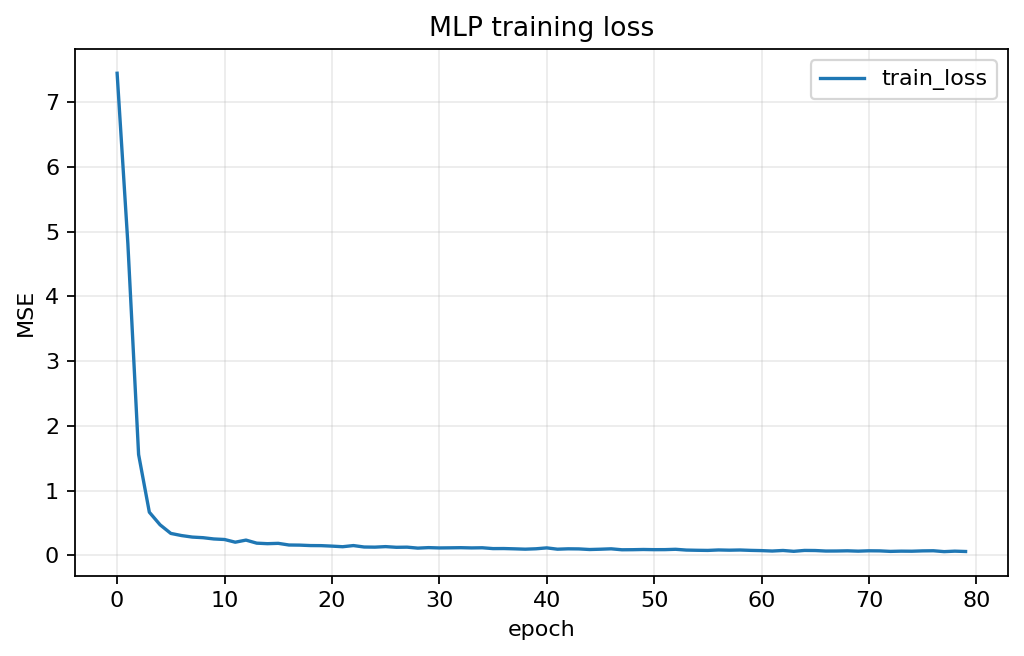

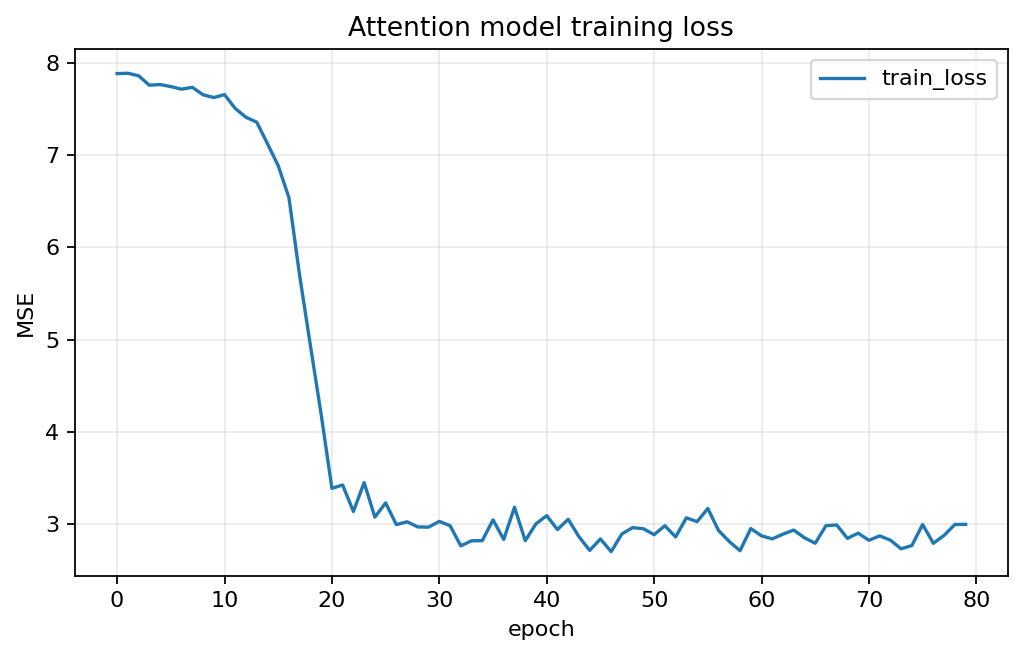

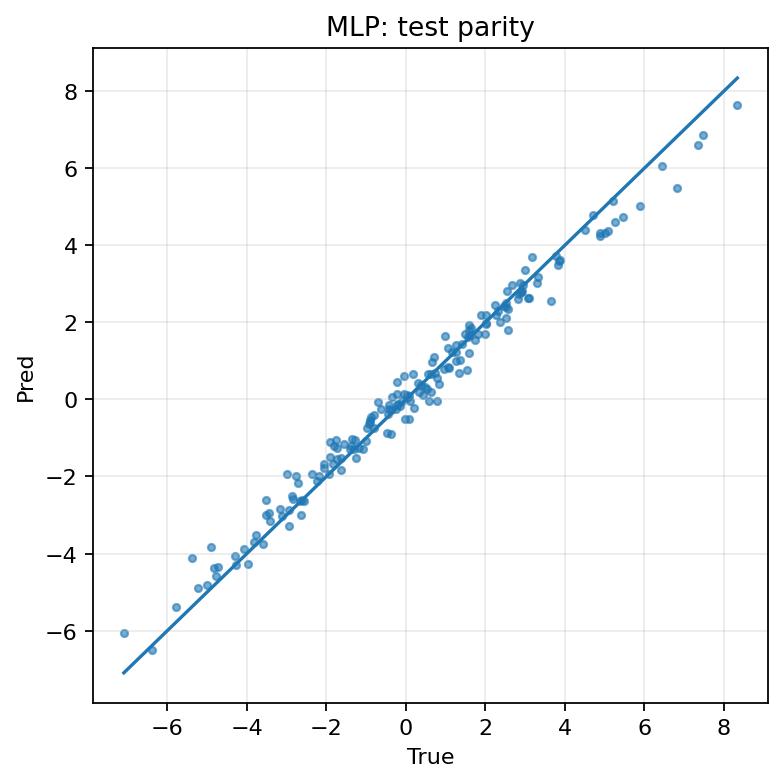

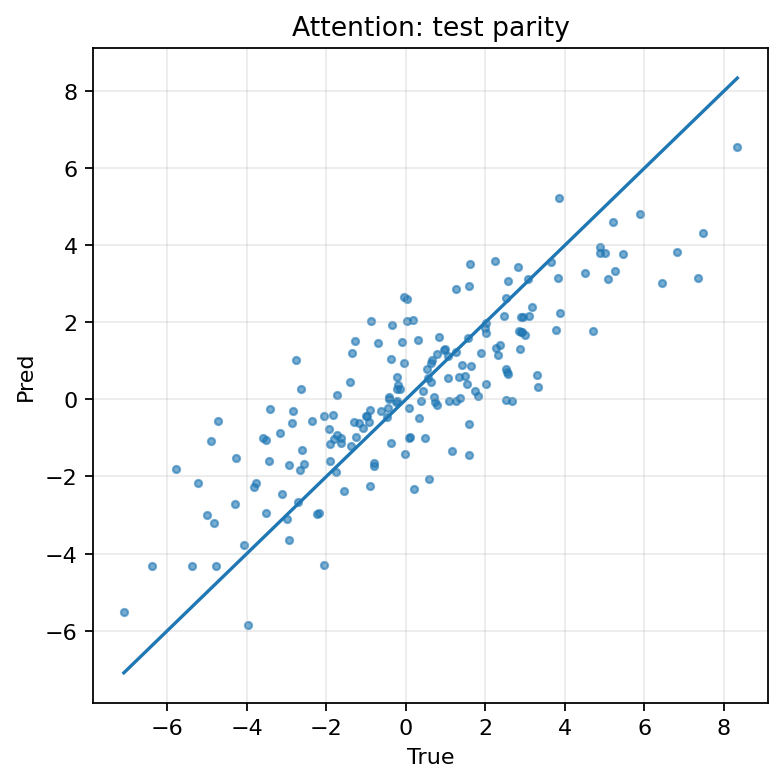

In [9]:
# ============================
# 6) Performance plots
# ============================
def plot_history(hist, title):
    fig, ax = plt.subplots(figsize=(6.5,4.2), dpi=160)
    ax.plot(hist["train_loss"], label="train_loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_mlp, "MLP training loss")
plot_history(hist_attn, "Attention model training loss")

def parity(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5.0,5.0), dpi=160)
    ax.scatter(y_true, y_pred, s=10, alpha=0.6)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx])
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

parity(y_true, y_pred, "MLP: test parity")
parity(y_true_a, y_pred_a, "Attention: test parity")

## 7) Explainability: Attention over features

For the attention model:
- `attn_test` has shape `(N_test, D_features)`
- each row sums to 1 and indicates which features were weighted more for that prediction

We visualize:
- **Global mean attention** (feature importance averaged over test samples)
- **Per-sample attention** for a few examples

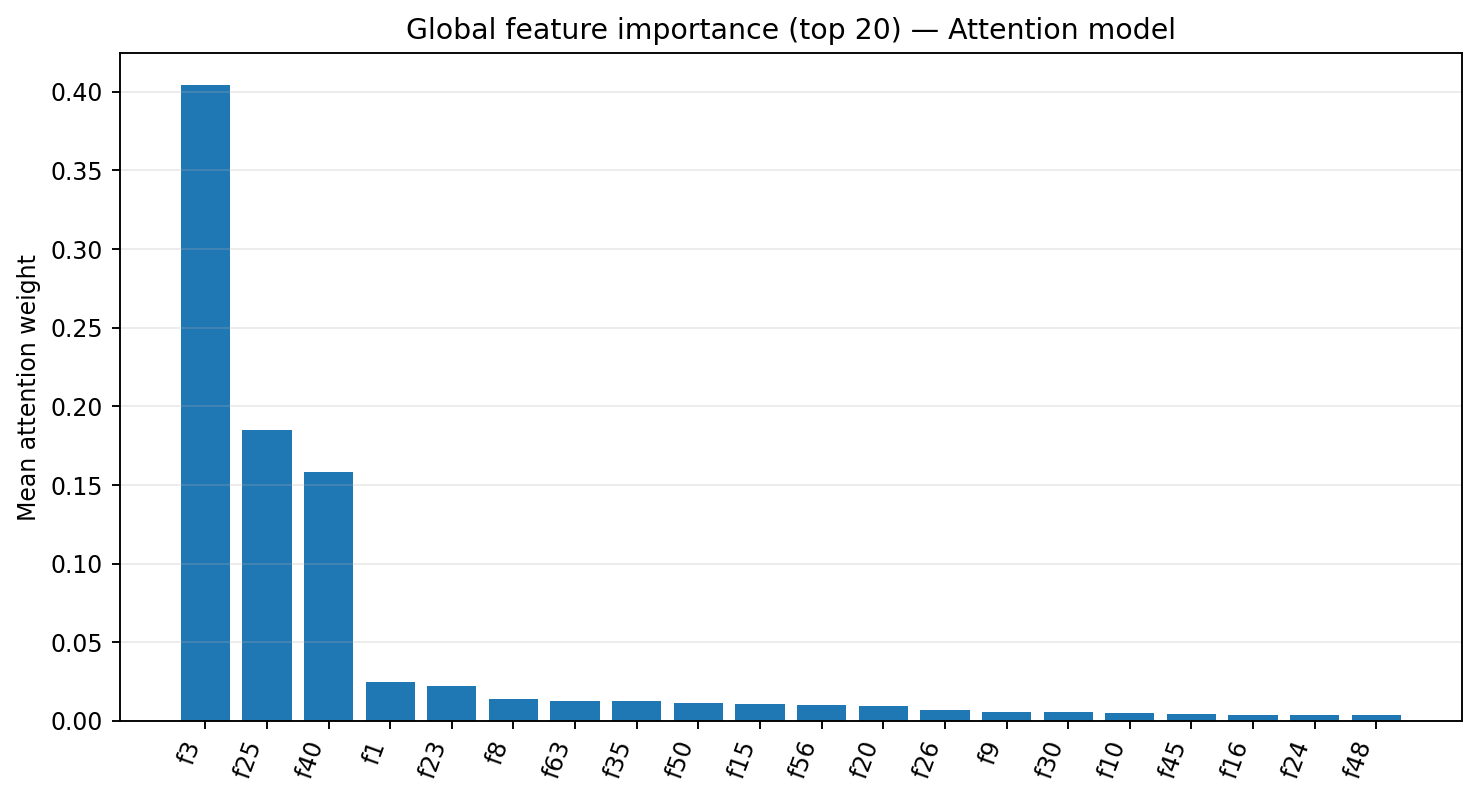

In [10]:
# ============================
# 7A) Global mean attention (top-k)
# ============================
attn_mean = attn_test.mean(axis=0)  # (D,)
order = np.argsort(attn_mean)[::-1]

topk = 20 if len(feature_names) > 20 else len(feature_names)
top_idx = order[:topk]

fig, ax = plt.subplots(figsize=(8.8,4.8), dpi=170)
ax.bar(range(topk), attn_mean[top_idx])
ax.set_xticks(range(topk))
ax.set_xticklabels([feature_names[i] for i in top_idx], rotation=70, ha="right")
ax.set_ylabel("Mean attention weight")
ax.set_title(f"Global feature importance (top {topk}) — Attention model")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

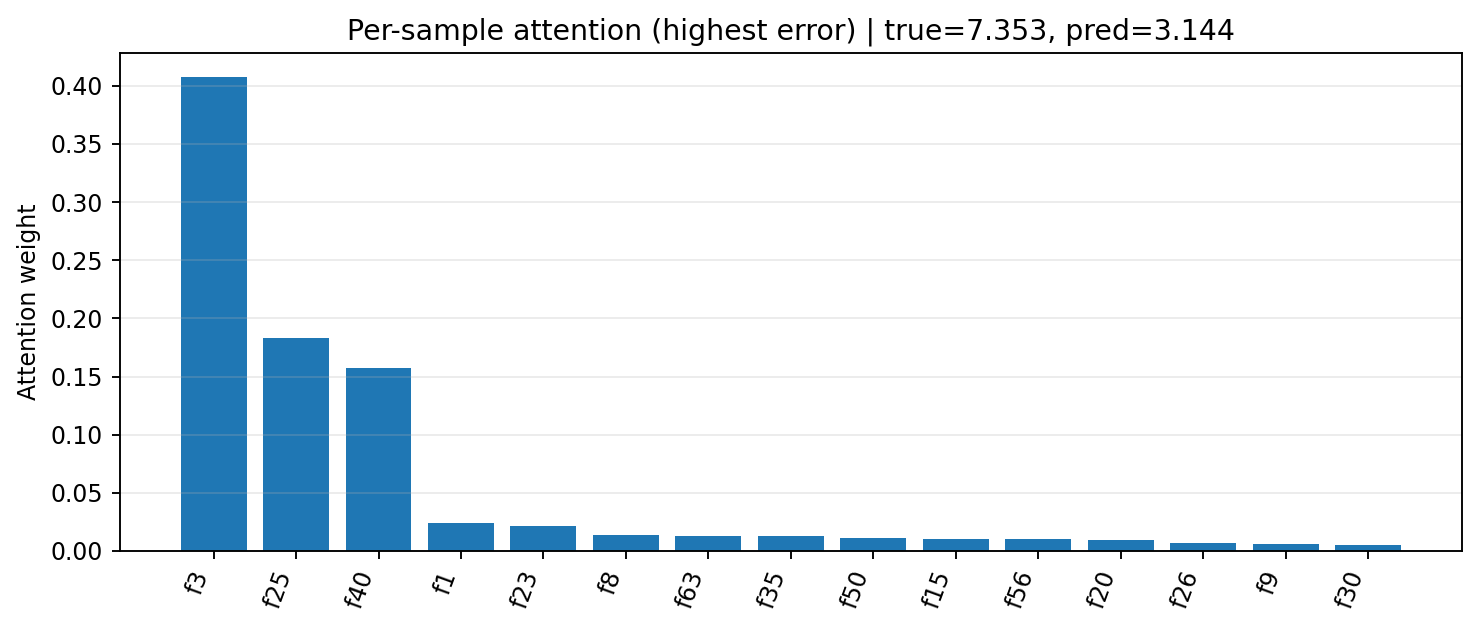

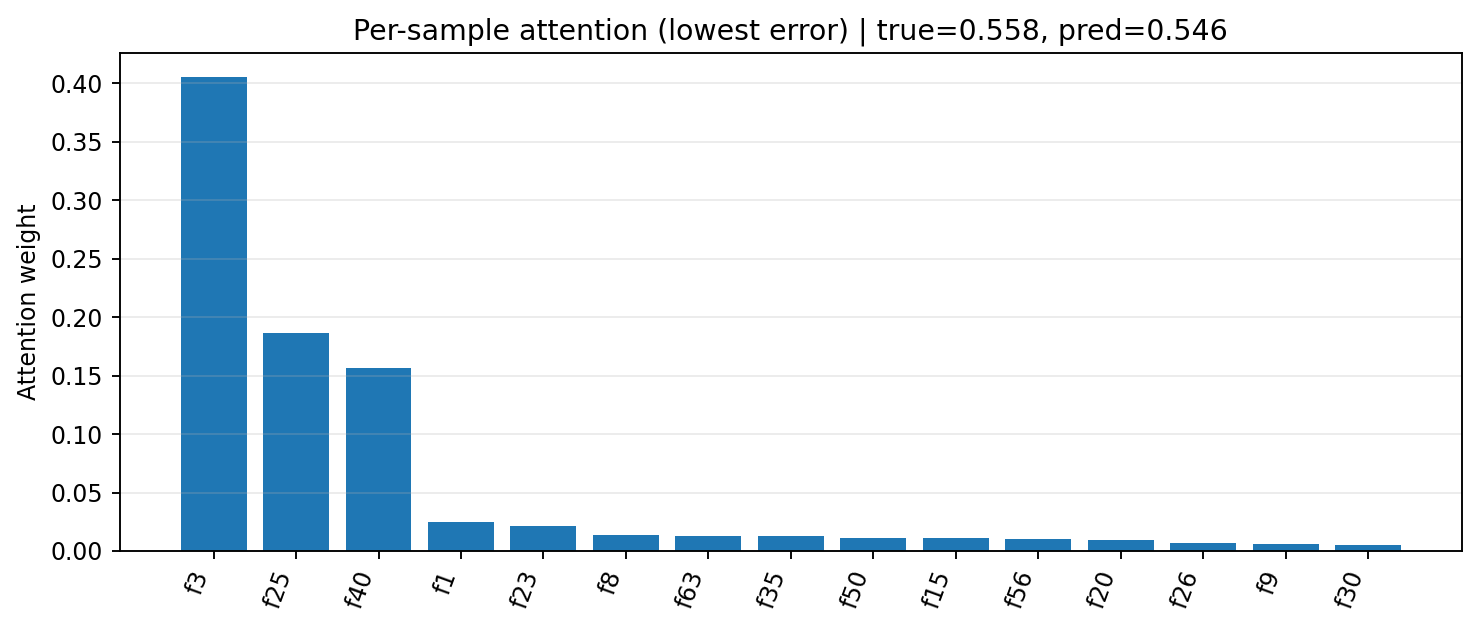

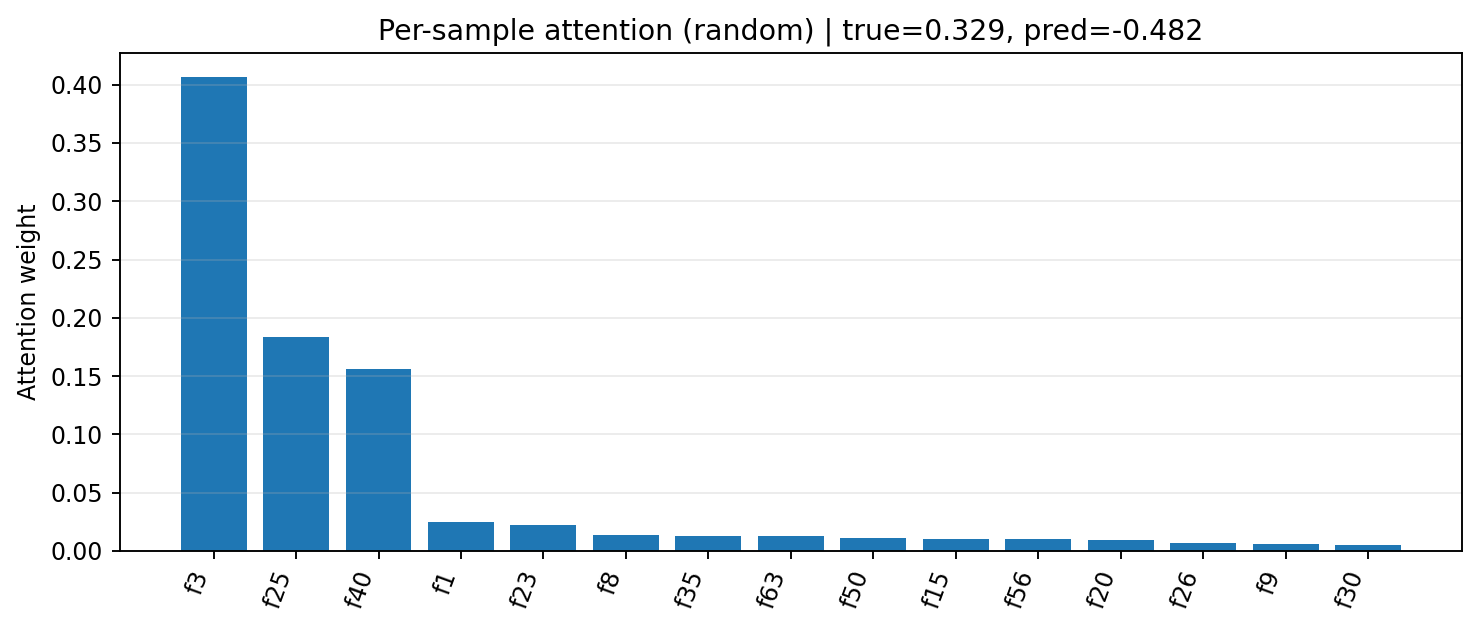

In [11]:
# ============================
# 7B) Per-sample attention (top features)
# ============================
err = np.abs(y_true_a - y_pred_a)
idx_hi = int(np.argmax(err))
idx_lo = int(np.argmin(err))
idx_r  = int(np.random.default_rng(0).integers(0, len(err)))

for idx, name in [(idx_hi, "highest error"), (idx_lo, "lowest error"), (idx_r, "random")]:
    a = attn_test[idx]
    o = np.argsort(a)[::-1][:15]
    fig, ax = plt.subplots(figsize=(8.8,3.8), dpi=170)
    ax.bar(range(len(o)), a[o])
    ax.set_xticks(range(len(o)))
    ax.set_xticklabels([feature_names[i] for i in o], rotation=70, ha="right")
    ax.set_ylabel("Attention weight")
    ax.set_title(f"Per-sample attention ({name}) | true={y_true_a[idx]:.3f}, pred={y_pred_a[idx]:.3f}")
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8) Optional: Causal sanity check via masking

A quick way to test whether attention is *meaningful*:

- For each sample, set the **top‑k attended features** to zero (in standardized space) and re‑predict.
- Compare prediction drop to masking random features.

If masking top‑attention features degrades predictions much more than random masking, attention is likely capturing real signal.

Mean |Δpred| after masking top-5:    1.7044
Mean |Δpred| after masking random-5: 0.2101


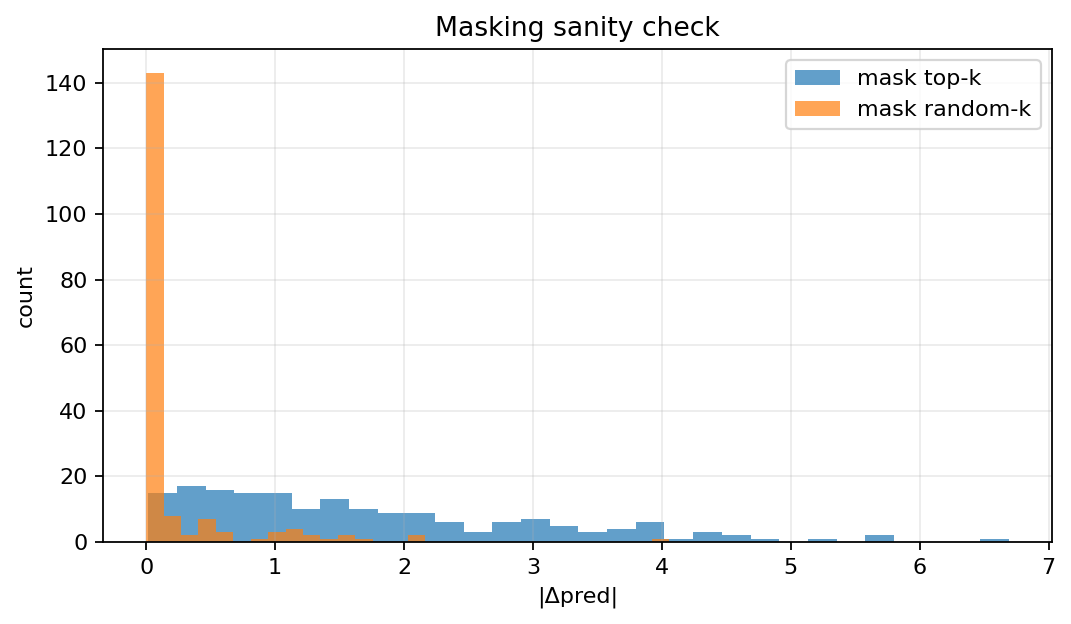

In [12]:
# ============================
# 8A) Masking test (top-k vs random)
# ============================
def predict_attention_model(model, Xnp):
    model.eval()
    with torch.no_grad():
        xb = torch.from_numpy(Xnp.astype(np.float32)).to(DEVICE)
        yh, attn = model(xb)
    return yh.detach().cpu().numpy().ravel(), attn.detach().cpu().numpy()

M = min(300, X_test.shape[0])
Xsub = X_test[:M].copy()

pred0, attn0 = predict_attention_model(attn_model, Xsub)

k = 5
rng = np.random.default_rng(0)
X_top = Xsub.copy()
X_rnd = Xsub.copy()

for i in range(M):
    top = np.argsort(attn0[i])[::-1][:k]
    rnd = rng.choice(Xsub.shape[1], size=k, replace=False)
    X_top[i, top] = 0.0
    X_rnd[i, rnd] = 0.0

pred_top, _ = predict_attention_model(attn_model, X_top)
pred_rnd, _ = predict_attention_model(attn_model, X_rnd)

drop_top = np.mean(np.abs(pred0 - pred_top))
drop_rnd = np.mean(np.abs(pred0 - pred_rnd))

print(f"Mean |Δpred| after masking top-{k}:    {drop_top:.4f}")
print(f"Mean |Δpred| after masking random-{k}: {drop_rnd:.4f}")

fig, ax = plt.subplots(figsize=(6.8,4.0), dpi=160)
ax.hist(np.abs(pred0 - pred_top), bins=30, alpha=0.7, label="mask top-k")
ax.hist(np.abs(pred0 - pred_rnd), bins=30, alpha=0.7, label="mask random-k")
ax.set_xlabel("|Δpred|")
ax.set_ylabel("count")
ax.set_title("Masking sanity check")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 9) Using your own data (quick checklist)

- ✅ **Row alignment:** each row corresponds to exactly one sample and one target.
- ✅ **Numeric features:** all feature columns are numeric.
- ✅ **No leakage:** don’t include target-derived columns as features.
- ✅ **Scaling:** `StandardScaler` is recommended for mixed-scale descriptors.
- ✅ **Holdout split:** if you have batch/wafer structure, consider grouped splits.

### Common extensions
- Multi-target prediction (vector y)
- Feature grouping (composition vs process vs microstructure) and group-wise attention
- Stability across seeds (average attention + variance)